
Student Names:
* Zach Milner
* Nhu Nguyen

# Project Goal:
The goal of this project is to analyze and model the relationship between customer income and their basket dollar amount (total spending). Specifically, we aim to:

1. Understand Spending Patterns
* Investigate how customers’ income levels correlate with their total spending.
* Identify trends, outliers, or clusters in the data.

2. Predict Customer Spending
* Build a predictive model (e.g., KNN or other regression models) that estimates a customer’s basket dollar amount based on their income.
* Evaluate model accuracy and identify which factors influence spending most strongly.

3. Visualize Relationship
* Create scatter plots comparing actual vs predicted spending.
  
# Importing Necessary Libraries

First we will import necessary libraries for cleaning and analyzing the file.

In [1]:
import json
import math
import os
import pandas as pd
import re
import sys

# Cleaning the Data

We will clean the data using this script.

In [2]:
#########################################
#
# Modify these parameters to specify the input and output filename.

INPUT_DATA_FILENAME: str = "FullData-Cao.csv"
CLEAN_DATA_FILENAME: str = "clean.csv"

#########################################

# Assume all types are str to get past data type issues.

dtype: dict = {
    "System Trans. ID": str,
    "HHID": str,
    "GeoID": str,
    "Trans Date": str,
    "Distinct Pro": str,
    "Basket Units": str,
    "Basket Dollar": str,
    "Day-of-Week": str,
    "Family Size": str,
    "Race": str,
    "Income": str,
    "Home Ownership": str,
    "Male Education": str,
    "Male Occupation": str,
    "Female Age": str,
    "Female Work": str,
    "Chldrn 0-5": str,
    "Chldrn 6-11": str,
    "Chldrn 12-17": str,
    "Markets": str,
    "Chains": str,
    "Outlets": str,
    "UPC": str,
    "UPC Description": str,
    "Category": str,
    "Vendor": str,
    "Brand": str,
    "SKU Dollars": str,
    "SKU Units": str,
    "Size": str,
    "SizeUnit": str,
    "": str,
    "": str,
    "": str,
    "": str
}

# Search for broken 1000s and fix them.

print("Fixing added commas for 1000s...")

with open(INPUT_DATA_FILENAME, "r") as file_in:
    with open("intermediate.csv", "w+") as file_inter:
        for line in file_in.readlines():
            file_inter.write(re.sub(r'(\d{,3}),(\d{3})(?!\d)', r'\1\2', line))

# Read the csv using pandas into a data frame called df.

print("Loading intermediate file into DataFrame...")

df = pd.read_csv("intermediate.csv", dtype=dtype, low_memory=False, index_col=0)

# Remove columns given the name "Unnamed"

print("Removing columns named 'Unnamed'...")

unnamed_cols = [col for col in df.columns if 'Unnamed' in col]
df.drop(columns=unnamed_cols, inplace=True)

# Remove NaN values

print("Removing NaN values...")

df = df.dropna()
print(df.head())

# Remove columns with only one unique value
single_val_cols = [col for col in df.columns if df[col].nunique() == 1]

print("Single unique value columns:")
print(single_val_cols)

for col in single_val_cols:
    print(f"{col}: {df[col].unique()}")

df.drop(columns=single_val_cols, inplace=True)

# Output cleaned file.

df.to_csv(CLEAN_DATA_FILENAME, index = False)

print(f"Exported cleaner dataset {CLEAN_DATA_FILENAME}")

Fixing added commas for 1000s...
Loading intermediate file into DataFrame...
Removing columns named 'Unnamed'...
Removing NaN values...
                       HHID GeoID      Trans Date Distinct Pro Basket Units  \
System Trans. ID                                                              
3269900001        124500669     3  10/2/2002 0:00           18           27   
3269900001        124500669     3  10/2/2002 0:00           18           27   
3269900001        124500669     3  10/2/2002 0:00           18           27   
3269900001        124500669     3  10/2/2002 0:00           18           27   
3269900001        124500669     3  10/2/2002 0:00           18           27   

                 Basket Dollar Day-of-Week Family Size      Race       Income  \
System Trans. ID                                                                
3269900001               69.67   Wednesday           5  Hispanic  75000-99999   
3269900001               69.67   Wednesday           5  Hispanic  7

Loading intermediate file into DataFrame...


Removing columns named 'Unnamed'...


Removing NaN values...


                       HHID GeoID      Trans Date  ... SKU Units  Size SizeUnit
System Trans. ID                                   ...                         
3269900001        124500669     3  10/2/2002 0:00  ...         1     4       OZ
3269900001        124500669     3  10/2/2002 0:00  ...         1    12       OZ
3269900001        124500669     3  10/2/2002 0:00  ...         0   Oth       er
3269900001        124500669     3  10/2/2002 0:00  ...         3     4       PT
3269900001        124500669     3  10/2/2002 0:00  ...         1     4       PT



[5 rows x 30 columns]


Single unique value columns:


[]


Exported cleaner dataset clean.csv


# Split the Data

We can now split the data into training data and testing data.

In [3]:
#########################################
#
# Modify these parameters to specify the input and output filename.

CLEAN_DATA_FILENAME: str = "clean.csv"
TRAIN_DATA_FILENAME: str = "train.csv"
TEST_DATA_FILENAME: str = "test.csv"

#########################################


def split_data(df, test_size = 0.3, random_state=42):
    df = df.sample(frac=1, random_state = random_state).reset_index(drop=True) #drop = True

    split_index = int((1-test_size)*len(df))

    train_df = df[:split_index]
    test_df = df[split_index:]

    return train_df, test_df

print("Loading cleaned data...")

df = pd.read_csv(CLEAN_DATA_FILENAME)

print("Splitting data...")

train_df, test_df = split_data(df, test_size = 0.3)

#output files

print("Outputting training and testing data...")

train_df.to_csv(TRAIN_DATA_FILENAME, index=False)
test_df.to_csv(TEST_DATA_FILENAME, index=False)

print(f"exported train.csv to 70% and test.csv to 30%")

Loading cleaned data...


C:\Users\olafn\AppData\Local\Temp\ipykernel_41760\3861566241.py:24: DtypeWarning: Columns (5,7,21,26,27) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(CLEAN_DATA_FILENAME)


Splitting data...
Outputting training and testing data...
exported train.csv to 70% and test.csv to 30%


# Analyzing the Data

We will use a k-nearest neighbors (KNN) model to analyze this dataset and predict household Basket Dollar values based on income.

First, we train the model using the available data, allowing it to learn patterns that relate Income to Basket Dollar spending.

In [11]:
#########################################
#
# Modify these parameters to specify the clean data filename,
# model filename and the position funciton for the model.

TRAIN_DATA_FILENAME: str = "train.csv"
MODEL_FILENAME: str = "model.csv"
POSITION_FUNCTION = lambda x: float(x["Income"])

#########################################

dtype: dict = {
    "HHID": str,
    "GeoID": str,
    "Trans Date": str,
    "Distinct Pro": str,
    "Basket Units": str,
    "Basket Dollar": str,
    "Day-of-Week": str,
    "Family Size": str,
    "Race": str,
    "Income": str,
    "Home Ownership": str,
    "Male Education": str,
    "Male Occupation": str,
    "Female Age": str,
    "Female Work": str,
    "Chldrn 0-5": str,
    "Chldrn 6-11": str,
    "Chldrn 12-17": str,
    "Markets": str,
    "Chains": str,
    "Outlets": str,
    "UPC": str,
    "UPC Description": str,
    "Category": str,
    "Vendor": str,
    "Brand": str,
    "SKU Dollars": str,
    "SKU Units": str,
    "SizeUnit": str
}

#helpwr function
def parse_income(income_str):
    #Convert income range like '75000-99999' to avg
    try:
        parts = income_str.split("-")
        if len(parts) == 2:
            return (float(parts[0]) + float(parts[1])) / 2
        else:
            return float(parts[0])
    except:
        return None

def valid(x) -> bool:
    return not (math.isnan(x["Basket Dollar"]) or math.isnan(x["Income"]))

class KNN:
    def __init__(self, k: int, evaluator) -> None:
        self.k: int = k
        self.evaluator = evaluator
        self.data: list = []

    def train(self, data: pd.DataFrame):
        self.data = list(
            filter(lambda y: y is not None,
                map(
                    lambda x: (self.evaluator(x[1]), x[1]) if valid(x[1]) else None,
                    data.iterrows()
                )
            )
        )
        
        self.data.sort(key=lambda x: x[0])

    def load_from_csv(self, filename: str) -> None:
        df = pd.read_csv(filename)
        self.data = list(
            map(
                lambda x: (x[1]["position_value"], x[1]),
                df.iterrows()
            )
        )

    def save_to_csv(self, filename: str) -> None:
        data: list = list(map(
            lambda x: dict({"position_value": x[0]}, **x[1]),
            self.data
        ))

        pd.DataFrame(data=data).to_csv(filename, index=False)

    def classify(self, datapoint: dict, answerer):
        point_value = self.evaluator(datapoint)

        step_size = len(self.data) // 2
        list_pos = step_size

        while point_value != self.data[list_pos][0] and step_size > 1:
            step_size = step_size // 2
            if self.data[list_pos][0] > point_value:
                list_pos -= step_size
            else:
                list_pos += step_size

        neighbors: list = []
        left_move: int = 1
        right_move: int = 0

        while len(neighbors) < self.k:
            if list_pos - left_move >= 0:
                left_dist: int = abs(
                    self.data[list_pos - left_move][0] - point_value
                )
            else:
                left_dist: int = sys.maxsize

            if list_pos + right_move < len(self.data):
                right_dist: int = abs(
                    self.data[list_pos + right_move][0] - point_value
                )
            else:
                right_dist: int = sys.maxsize

            if right_dist < left_dist:
                neighbors.append(self.data[list_pos + right_move])
                right_move += 1
                continue

            neighbors.append(self.data[list_pos - left_move])
            left_move += 1

        return answerer(neighbors)

    #compute error instead
    def test(self, df: pd.DataFrame, answerer) -> float:
        total_error = 0
        count = 0

        for row in df.iterrows():
            if not valid(row[1]):
                continue
    
            predicted = self.classify(row[1], answerer)
            actual = float(row[1]["Basket Dollar"])
    
            total_error += abs(predicted - actual)
            count += 1
    
        return total_error / count if count > 0 else 0

# We set k to 0 because it will not be saved when training.

knn: KNN = KNN(0, POSITION_FUNCTION)

print("Training will take a moment!")

#force to numeric conversion
train_df = pd.read_csv(TRAIN_DATA_FILENAME, dtype=dtype)

train_df["Income"] = train_df["Income"].apply(parse_income)
train_df["Basket Dollar"] = pd.to_numeric(train_df["Basket Dollar"], errors="coerce") #just in case

#again, just in case :D
train_df = train_df.dropna(subset=["Income", "Basket Dollar"])

knn.train(train_df)
knn.save_to_csv(MODEL_FILENAME)

print(f"Output {MODEL_FILENAME}")

Training will take a moment!
Output model.csv


# Test Model

After training, we evaluate the model using a separate test dataset to measure its performance. The model predicts Basket Dollar values for each household in the test set, and we compare these predictions with the actual values to compute the mean absolute error (MAE). This allows us to quantify how accurately the model estimates household spending.

In [12]:
#########################################
#
# Modify these parameters to specify the input and output filename.

MODEL_FILENAME: str = "model.csv"
TEST_DATA_FILENAME: str = "test.csv"
K_VALUE: int = 5

def answerer(neighbors): #we can use average instead
    total = 0
    for neighbor in neighbors:
        total += float(neighbor[1]["Basket Dollar"])
    return total / len(neighbors)

knn: KNN = KNN(K_VALUE, POSITION_FUNCTION)

print("Loading model...")

knn.load_from_csv(MODEL_FILENAME)

print("Estimate error...")

#load test data
test_df = pd.read_csv(TEST_DATA_FILENAME, dtype=dtype)

# Clean numeric fields
test_df["Income"] = test_df["Income"].apply(parse_income) #from our helper function
test_df["Basket Dollar"] = pd.to_numeric(test_df["Basket Dollar"], errors="coerce")
test_df = test_df.dropna(subset=["Income", "Basket Dollar"])

#now run test
print(f"Mean Absolute Error: {knn.test(test_df, answerer)}")

Loading model...


C:\Users\olafn\AppData\Local\Temp\ipykernel_41760\2433846678.py:78: DtypeWarning: Columns (22,27,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filename)


Estimate error...
Mean Absolute Error: 25.159519581232285


ParserError: Error tokenizing data. C error: Expected 1 fields in line 31, saw 2


# Visualizing Predictions

To better understand how well the model performs, we can plot the predicted Basket Dollar values against the actual values from the test dataset. This visualization helps us see if the predictions generally follow the true spending patterns and identify any trends, clusters, or outliers.

* Blue points represent the actual basket dollar amounts for each household.
* Red points represent the predicted basket dollar amounts using our trained KNN model.

From this scatter plot, we can see how the red points are mostly lower than the blue points, which indicates that the model is underestimating basket dollar amounts for higher-income households. Adding a y = x line could help visualize how close predictions are to the actual values.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

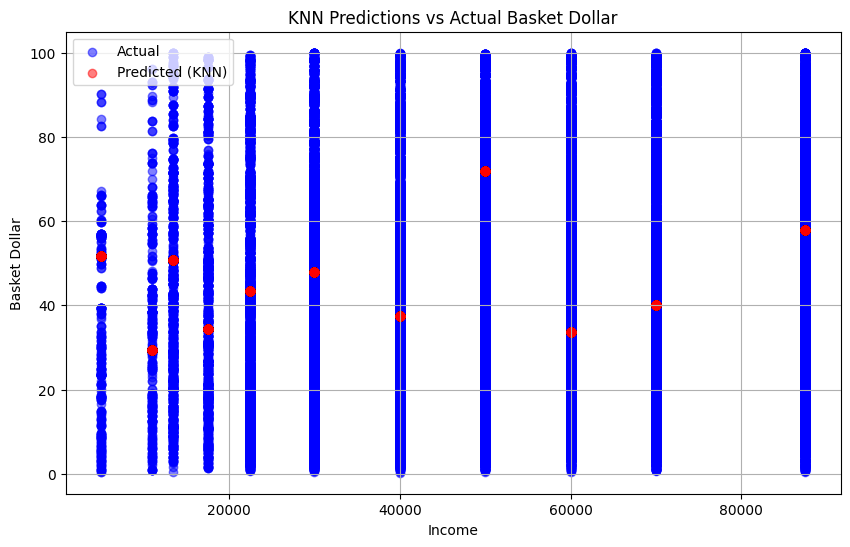

In [15]:
plt.figure(figsize=(10,6))
plt.scatter(test_df["Income"], test_df["Basket Dollar"], color='blue', alpha=0.5, label='Actual')

predictions = []
for _, row in test_df.iterrows():
    pred = knn.classify(row, answerer)
    predictions.append(pred)

plt.scatter(test_df["Income"], predictions, color='red', alpha=0.5, label='Predicted (KNN)')

plt.title("KNN Predictions vs Actual Basket Dollar")
plt.xlabel("Income")
plt.ylabel("Basket Dollar")
plt.legend()
plt.grid(True)  
plt.show()

# Conclusion
Using a K-Nearest Neighbors (KNN) model, we attempted to predict household basket spending based on income. The scatter plot shows that:
* The model captures some general trends, but there is noticeable underestimation for higher-income households.
* Predictions are more accurate for households with lower to mid-range incomes, while variability increases for higher incomes.
* The Mean Absolute Error (MAE) indicates that, on average, predictions deviate from actual basket dollar values by around 25 units.

This suggests that while KNN provides a basic approximation, further improvements could be made, such as:
* Using more features (like family size, household composition, or geographic factors).
* Trying different K values or distance metrics.
* Considering more advanced regression models for continuous outcomes.
* 
Overall, KNN gives a rough estimate of basket spending, but more sophisticated models may improve predictive accuracy.